In [10]:
# Installing `caer` and `canaro` since they don't come pre-installed
!pip install --upgrade caer canaro

ERROR: Could not find a version that satisfies the requirement canaro (from versions: none)
ERROR: No matching distribution found for canaro


In [53]:
import os
import caer
import numpy as np
import cv2 as cv
import gc
#pylint:disable=no-member (Removes linting problems with cv)

In [54]:
IMG_SIZE = (80,80)
channels = 1
char_path = r'/kaggle/input/datasets/alexattia/the-simpsons-characters-dataset/simpsons_dataset'

In [55]:
# Creating a character dictionary, sorting it in descending order
char_dict = {}
for char in os.listdir(char_path):
    char_dict[char] = len(os.listdir(os.path.join(char_path,char)))

# Sort in descending order
char_dict = caer.sort_dict(char_dict, descending=True)
char_dict

[('homer_simpson', 2246),
 ('ned_flanders', 1454),
 ('moe_szyslak', 1452),
 ('lisa_simpson', 1354),
 ('bart_simpson', 1342),
 ('marge_simpson', 1291),
 ('krusty_the_clown', 1206),
 ('principal_skinner', 1194),
 ('charles_montgomery_burns', 1193),
 ('milhouse_van_houten', 1079),
 ('chief_wiggum', 986),
 ('abraham_grampa_simpson', 913),
 ('sideshow_bob', 877),
 ('apu_nahasapeemapetilon', 623),
 ('kent_brockman', 498),
 ('comic_book_guy', 469),
 ('edna_krabappel', 457),
 ('nelson_muntz', 358),
 ('lenny_leonard', 310),
 ('mayor_quimby', 246),
 ('waylon_smithers', 181),
 ('maggie_simpson', 128),
 ('groundskeeper_willie', 121),
 ('barney_gumble', 106),
 ('selma_bouvier', 103),
 ('carl_carlson', 98),
 ('ralph_wiggum', 89),
 ('patty_bouvier', 72),
 ('martin_prince', 71),
 ('professor_john_frink', 65),
 ('snake_jailbird', 55),
 ('cletus_spuckler', 47),
 ('rainier_wolfcastle', 45),
 ('simpsons_dataset', 42),
 ('agnes_skinner', 42),
 ('sideshow_mel', 40),
 ('otto_mann', 32),
 ('fat_tony', 27),
 (

In [56]:
#  Getting the first 10 categories with the most number of images
characters = []
count = 0
for i in char_dict:
    characters.append(i[0])
    count += 1
    if count >= 10:
        break
characters

['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

In [57]:
# Create the training data
train = caer.preprocess_from_dir(char_path, characters, channels=channels, IMG_SIZE=IMG_SIZE, isShuffle=True)

[INFO] Could not find a file to load from. Generating the training data
----------------------------------------------
[INFO] At 1000 files
[INFO] At 2000 files
[INFO] 2246 files found in 1.231956958770752s
[INFO] At 1000 files
[INFO] 1454 files found in 1.078794240951538s
[INFO] At 1000 files
[INFO] 1452 files found in 1.0622031688690186s
[INFO] At 1000 files
[INFO] 1354 files found in 1.028853416442871s
[INFO] At 1000 files
[INFO] 1342 files found in 1.0386595726013184s
[INFO] At 1000 files
[INFO] 1291 files found in 1.0111498832702637s
[INFO] At 1000 files
[INFO] 1206 files found in 0.9869241714477539s
[INFO] At 1000 files
[INFO] 1194 files found in 1.0181055068969727s
[INFO] At 1000 files
[INFO] 1193 files found in 1.0158963203430176s
[INFO] At 1000 files
[INFO] 1079 files found in 1.0166850090026855s
----------------------------------------------
[INFO] 13811 files preprocessed! Took 0m 54s


In [58]:
# Number of training samples
len(train)

13811

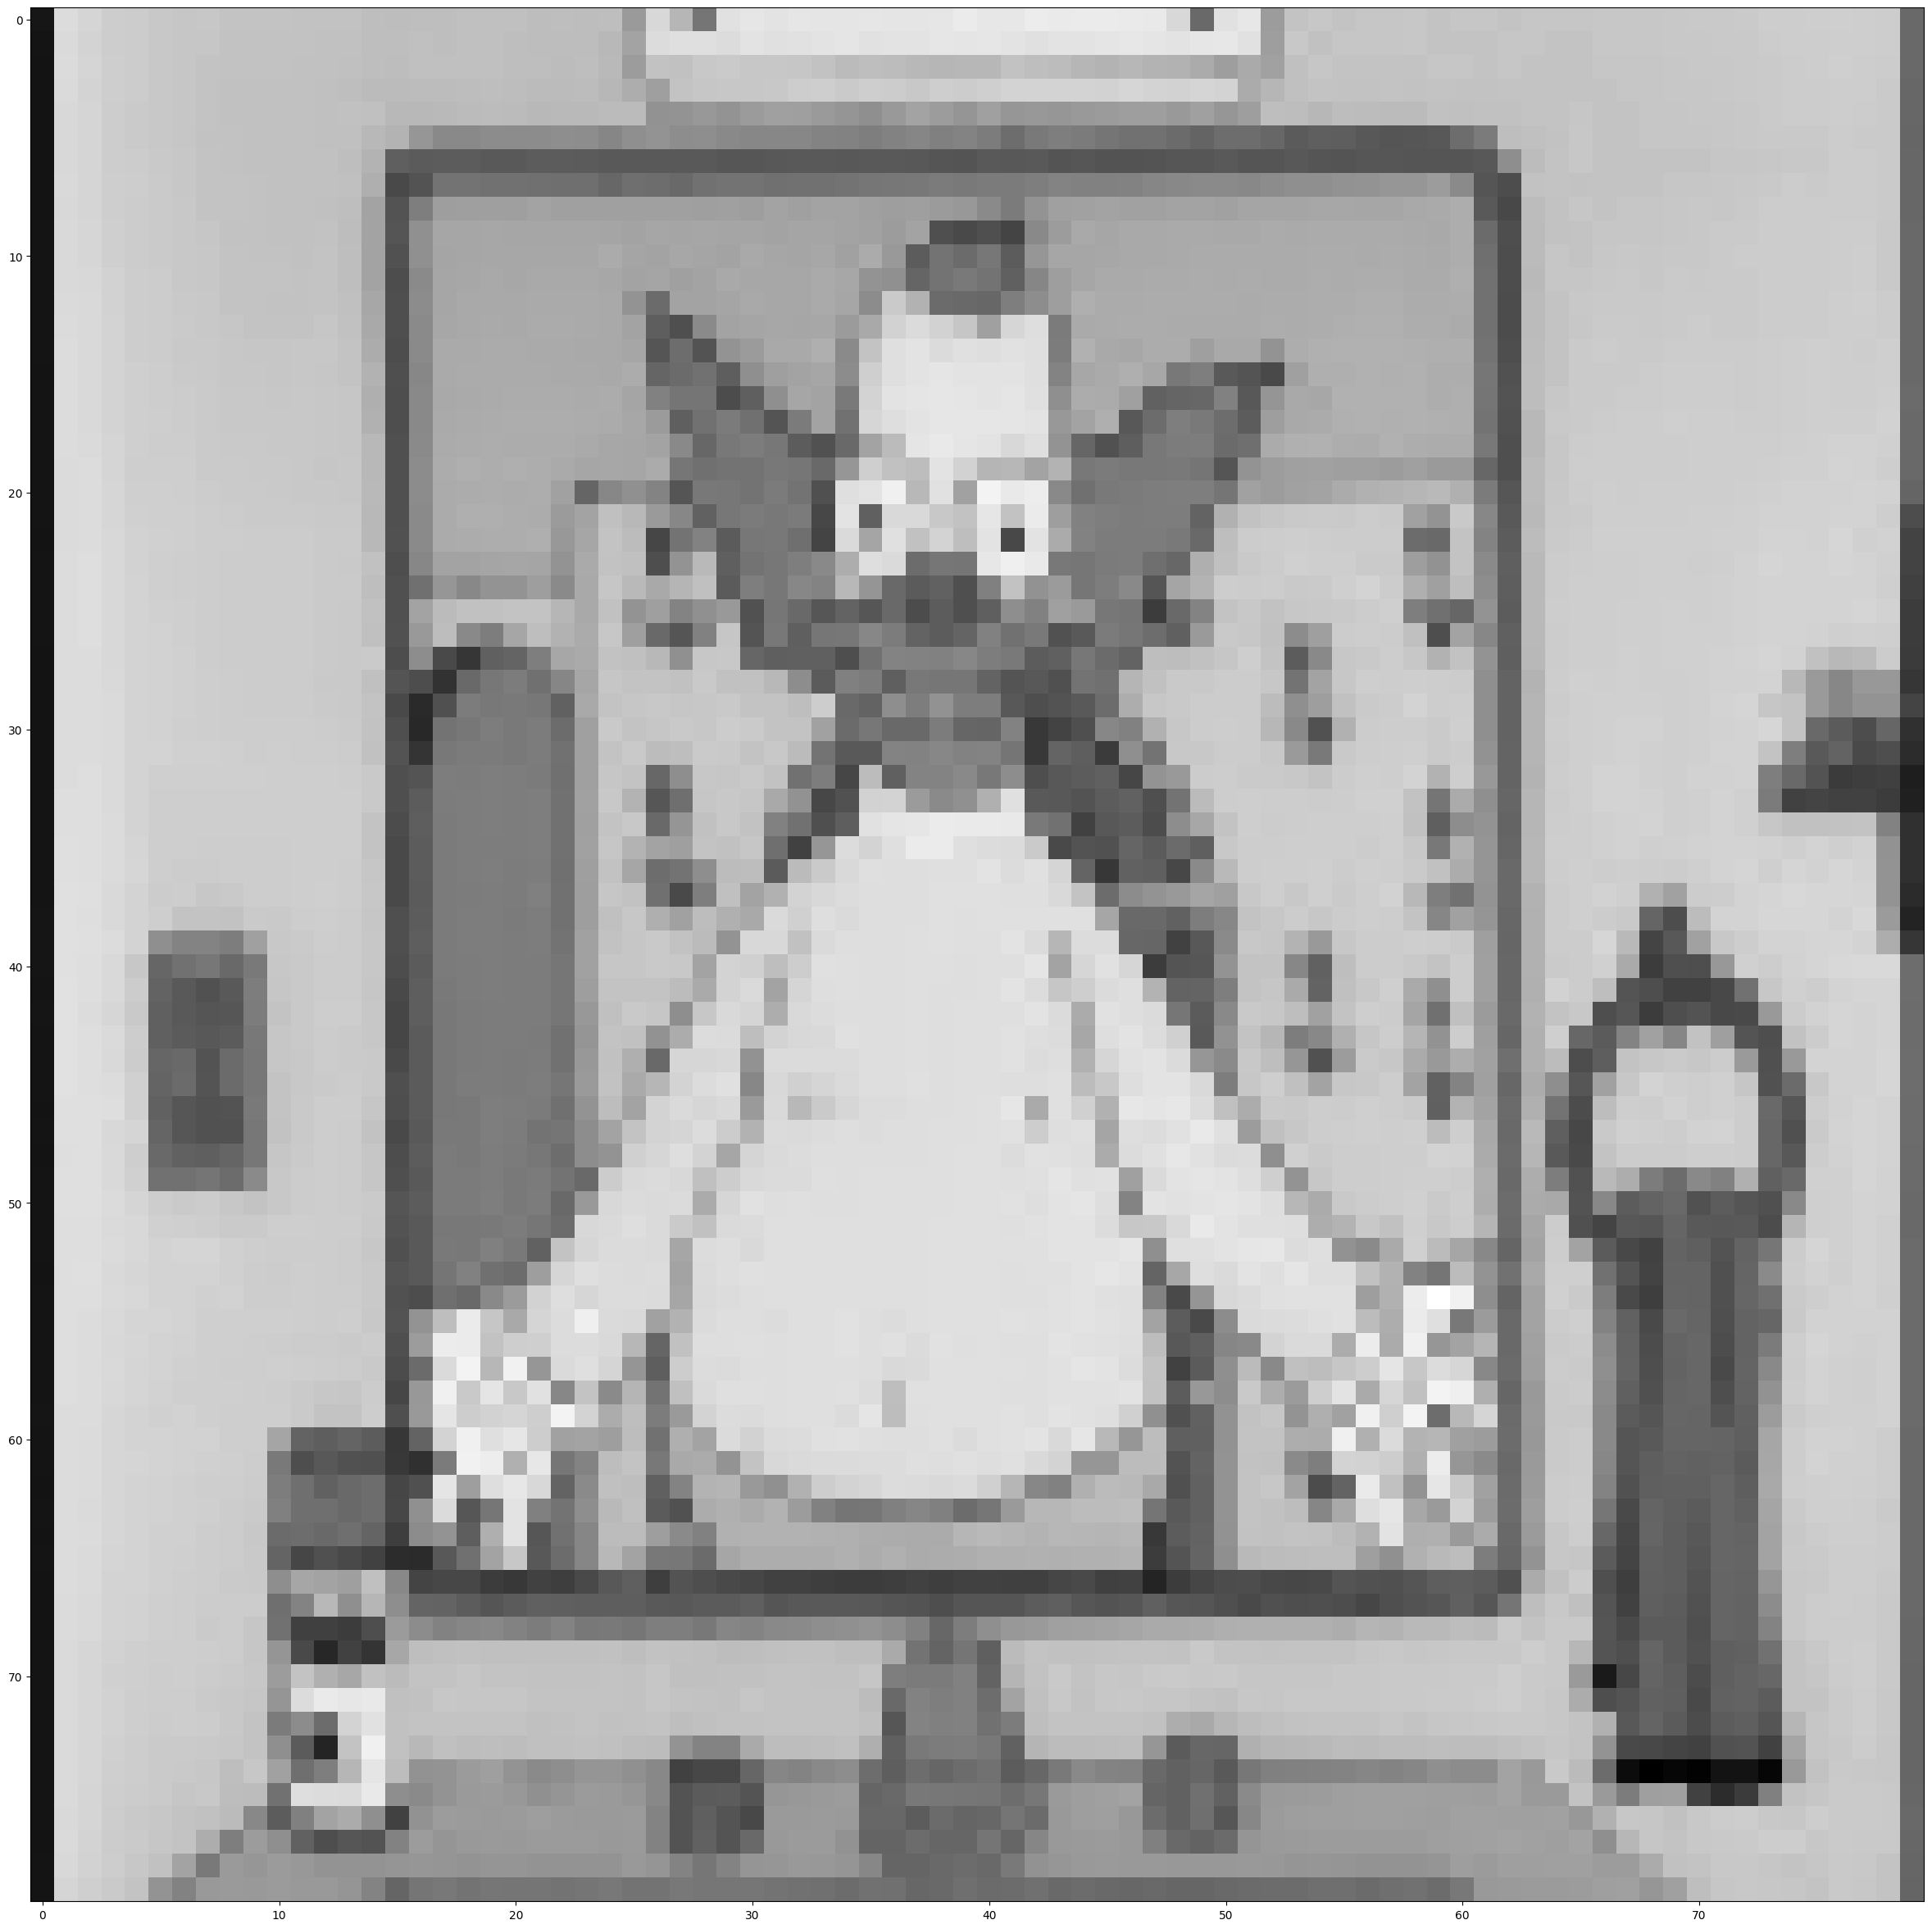

In [59]:
# Visualizing the data (OpenCV doesn't display well in Jupyter notebooks)
import matplotlib.pyplot as plt
plt.figure(figsize=(30,30))
plt.imshow(train[0][0], cmap='gray')
plt.show()

In [60]:
# Separating the array and corresponding labels
featureSet, labels = caer.sep_train(train, IMG_SIZE=IMG_SIZE)

In [61]:
from tensorflow.keras.utils import to_categorical

# Normalize the featureSet ==> (0,1)
# network can learn faster as compared to not normalizing the data. 
featureSet = caer.normalize(featureSet)
# Converting numerical labels to binary class vectors
labels = to_categorical(labels, len(characters))

In [62]:
x_train, x_val, y_train, y_val = caer.train_val_split(featureSet, labels, val_ratio=.2)

In [63]:
# remove memory?
del train
del featureSet
del labels 
gc.collect()

0

In [64]:
# Useful variables when training
BATCH_SIZE = 32
EPOCHS = 10

In [65]:
# synthesize new images from already existing images to help introduce randomness to our network
# helps it perform better
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow(x_train, y_train, batch_size=BATCH_SIZE)

In [66]:
# Create our model (returns a compiled model)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D

output_dim=10

w, h = IMG_SIZE[:2]

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(w, h,channels)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(256, (3, 3), padding='same', activation='relu')) 
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))

# Output Layer
model.add(Dense(output_dim, activation='softmax'))


In [67]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 80, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 78, 78, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 39, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 18, 18, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,591,274 (67.11 MB)

 Trainable params: 17,591,274 (67.11 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
# schedule the learning rate at specific intervals, so the network can train better

import tensorflow as tf

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.96
)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=lr_schedule,
    momentum=0.9,
    nesterov=True
)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [71]:
# Training the model

callbacks_list = []
training = model.fit(train_gen,
                    steps_per_epoch=len(x_train)//BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val,y_val),
                    validation_steps=len(y_val)//BATCH_SIZE,
                    callbacks = callbacks_list)

Epoch 1/10


I0000 00:00:1777193572.870700     185 service.cc:152] XLA service 0x78dbd4002b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777193572.870744     185 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777193573.260714     185 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/345 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.0957 - loss: 0.6927

I0000 00:00:1777193579.020798     185 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


345/345 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.1178 - loss: 0.4991 - val_accuracy: 0.1606 - val_loss: 0.3358
Epoch 2/10
  1/345 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1562 - loss: 0.3247

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1562 - loss: 0.3247 - val_accuracy: 0.1606 - val_loss: 0.3357
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1596 - loss: 0.3275 - val_accuracy: 0.1606 - val_loss: 0.3353
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0625 - loss: 0.3409 - val_accuracy: 0.1606 - val_loss: 0.3353
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1632 - loss: 0.3259 - val_accuracy: 0.1606 - val_loss: 0.3346
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2500 - loss: 0.3259 - val_accuracy: 0.1606 - val_loss: 0.3346
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1610 - loss: 0.3251 - val_accuracy: 0.1606 - val_loss: 0.3348
Epoch 8/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1250 - loss: 0.3262 - val_accuracy: 0.1606 - val_loss: 0.3348
Epoch 9/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.1681 - loss: 0.3245 - val_accuracy: 0.1606 - 

In [72]:
characters

['homer_simpson',
 'ned_flanders',
 'moe_szyslak',
 'lisa_simpson',
 'bart_simpson',
 'marge_simpson',
 'krusty_the_clown',
 'principal_skinner',
 'charles_montgomery_burns',
 'milhouse_van_houten']

## Testing

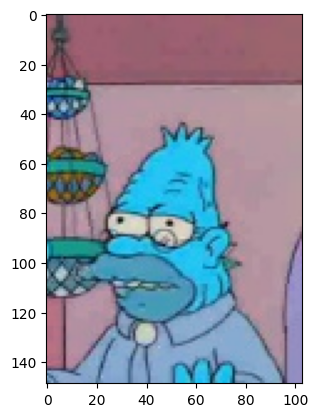

In [73]:
test_path = r'/kaggle/input/datasets/alexattia/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset/abraham_grampa_simpson_0.jpg'

img = cv.imread(test_path)

plt.imshow(img)
plt.show()

In [74]:
def prepare(image):
    image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    image = cv.resize(image, IMG_SIZE)
    image = caer.reshape(image, IMG_SIZE, 1)
    return image

In [75]:
predictions = model.predict(prepare(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step


In [76]:
# Getting class with the highest probability
print(characters[np.argmax(predictions[0])])

homer_simpson
